<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Week7_Day1_dalychallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Défi quotidien : Analyse textuelle de livres à l'aide d'un nuage de mots

Ce notebook contient les étapes de prétraitement NLP et d'analyse de texte pour les œuvres de Lewis Carroll.
```

In [24]:
import requests
import re
import nltk
import spacy
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Téléchargement des ressources NLTK nécessaires pour le traitement du texte
nltk.download('punkt')              # Pour diviser le texte en mots (tokenisation)
nltk.download('punkt_tab')          # Données requises pour le tokenizer
nltk.download('stopwords')          # Liste des mots fréquents à ignorer (mots vides)
nltk.download('averaged_perceptron_tagger') # Pour l'analyse grammaticale
nltk.download('averaged_perceptron_tagger_eng') # Version spécifique anglaise du tagger
nltk.download('maxent_ne_chunker')  # Pour détecter les noms propres (entités)
nltk.download('maxent_ne_chunker_tab') # Ressource manquante pour le chunker
nltk.download('words')               # Dictionnaire de référence pour NLTK

# Liste des adresses Web des livres de Lewis Carroll
urls = [
    'https://www.gutenberg.org/files/11/11-0.txt',
    'https://www.gutenberg.org/files/12/12-0.txt',
    'https://www.gutenberg.org/cache/epub/29691/pg29691.txt'
]

def load_texts(url_list):
    """Télécharge les livres et nettoie les caractères spéciaux."""
    corpus = []
    for url in url_list:
        # On récupère le contenu brut de la page
        response = requests.get(url)
        text = response.text
        # On ne garde que les lettres (A-Z) et les espaces avec une expression régulière
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)
        corpus.append(cleaned_text)
    return corpus

# Chargement initial des textes
raw_corpus = load_texts(urls)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping 

In [20]:
from nltk.tokenize import word_tokenize

def trim_text(text):
    """Retire les introductions et conclusions légales de Project Gutenberg."""
    start_marker = "START"
    end_marker = "END"
    start_idx = text.find(start_marker)
    end_idx = text.rfind(end_marker)
    # Si on trouve les balises, on extrait le texte situé entre elles
    return text[start_idx:end_idx] if (start_idx != -1 and end_idx != -1) else text

# 1. On nettoie les en-têtes et pieds de page
trimmed_corpus = [trim_text(t) for t in raw_corpus]

# 2. On transforme les textes en listes de mots en minuscules
tokenized_corpus = [word_tokenize(t.lower()) for t in trimmed_corpus]

# 3. Chargement de la liste des mots vides anglais (ex: 'the', 'is')
stop_words = set(stopwords.words('english'))

# 4. On garde uniquement les mots alphabétiques qui ne sont pas dans les mots vides
filtered_corpus = [[word for word in book if word.isalpha() and word not in stop_words] for book in tokenized_corpus]

print(f"Prétraitement réussi. Mots restants dans le livre 1 : {len(filtered_corpus[0])}")

Prétraitement réussi. Mots restants dans le livre 1 : 12684


Étiquettes POS (20 premiers) : [('start', 'NN'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('illustration', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('wonderland', 'VBP'), ('lewis', 'JJ'), ('carroll', 'NN'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('rabbithole', 'VBP'), ('chapter', 'NN'), ('ii', 'NN'), ('pool', 'NN'), ('tears', 'NNS')]

Entités identifiées : (S
  start/NN
  project/NN
  gutenberg/NN
  ebook/NN
  illustration/NN
  alices/NNS
  adventures/VBZ
  wonderland/VBP
  lewis/JJ
  carroll/NN
  millennium/NN
  fulcrum/NN
  edition/NN
  contents/NNS
  chapter/NN
  rabbithole/VBP
  chapter/NN
  ii/NN
  pool/NN
  tears/NNS)


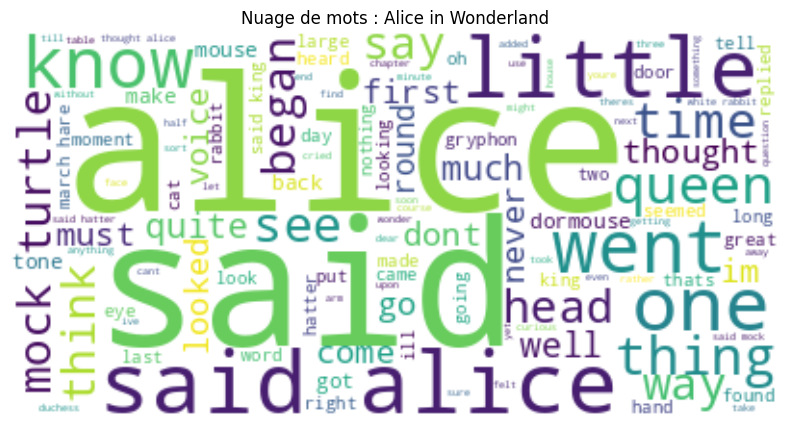

In [25]:
# --- Étape 8 : Identification de la nature des mots (POS Tagging) ---
# On analyse le rôle grammatical (Nom, Adjectif...) des 20 premiers mots
pos_tags = nltk.pos_tag(filtered_corpus[0][:20])
print("Étiquettes POS (20 premiers) :", pos_tags)

# --- Étape 9 : Reconnaissance d'entités (NER) ---
# Identifie les entités nommées comme les personnages ou les lieux
named_entities = nltk.ne_chunk(pos_tags)
print("\nEntités identifiées :", named_entities)

# --- Visualisation : Nuage de mots ---
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def show_wordcloud(text_list, title):
    """Crée une image montrant les mots les plus fréquents en plus gros."""
    # On génère le nuage de mots à partir du texte joint
    wordcloud = WordCloud(background_color='white').generate(" ".join(text_list))
    # Configuration de l'affichage graphique
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off") # On masque les graduations des axes
    plt.show()

# Génération du nuage de mots pour le premier livre
show_wordcloud(filtered_corpus[0], "Nuage de mots : Alice in Wonderland")

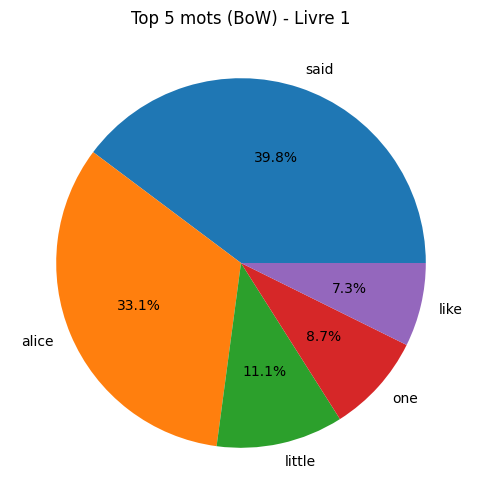

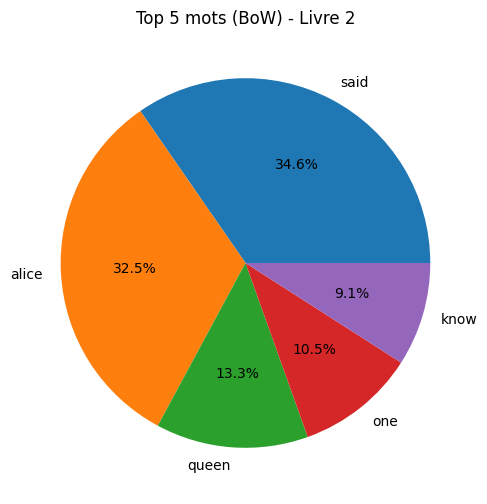

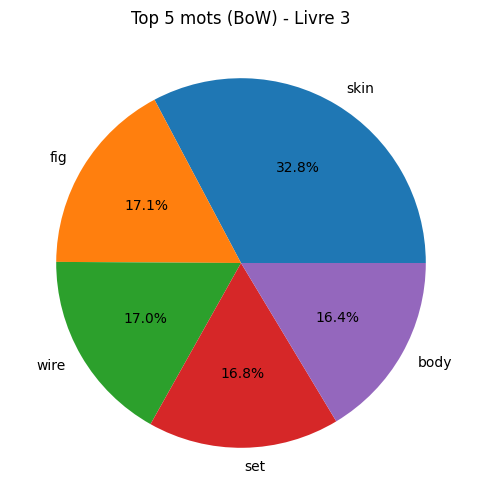


Analyse TF-IDF terminée.


In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt

# Conversion des listes de mots en chaînes de caractères pour les vectoriseurs
corpus_joined = [" ".join(book) for book in filtered_corpus]

# --- Méthode Bag of Words (BoW) ---
# On compte simplement le nombre d'apparitions de chaque mot
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus_joined)
feature_names = vectorizer.get_feature_names_out()

# On parcourt chaque livre pour afficher les 5 mots les plus fréquents
for i, book_text in enumerate(corpus_joined):
    counts = bow_matrix[i].toarray().flatten()
    # On trie pour trouver les 5 plus grands comptes
    top_indices = counts.argsort()[-5:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    top_counts = [counts[idx] for idx in top_indices]

    # Affichage du graphique en camembert
    plt.figure(figsize=(6, 6))
    plt.pie(top_counts, labels=top_words, autopct='%1.1f%%')
    plt.title(f"Top 5 mots (BoW) - Livre {i+1}")
    plt.show()

# --- Méthode TF-IDF ---
# Donne du poids aux mots rares et pénalise les mots trop fréquents (ex: 'alice')
tfidf_vec = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vec.fit_transform(corpus_joined)
tfidf_features = tfidf_vec.get_feature_names_out()

print("\nAnalyse TF-IDF terminée.")

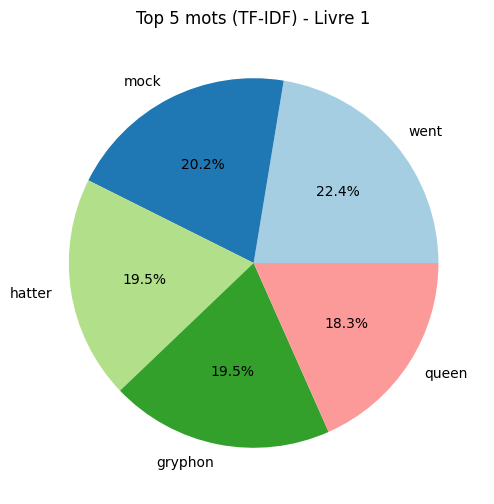

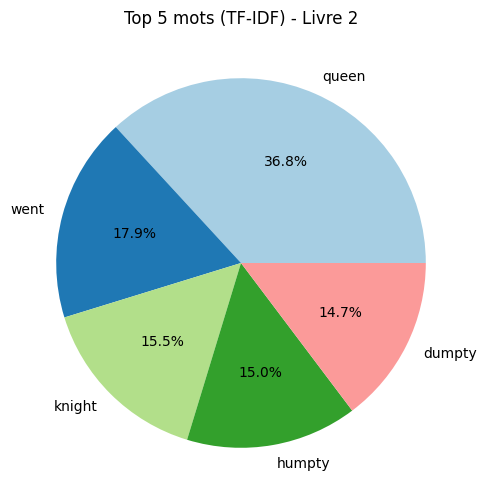

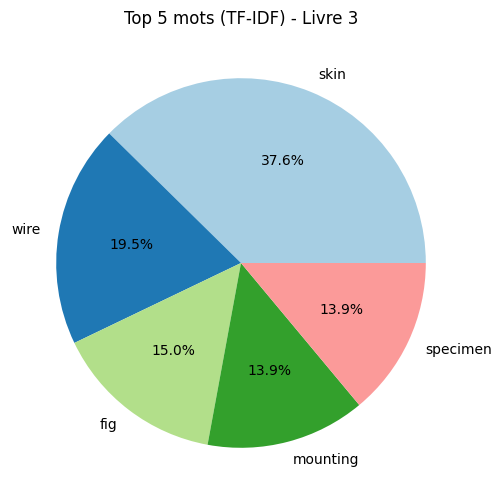

Analyse terminée ! Comparez avec BoW pour voir comment TF-IDF élimine les mots trop communs.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Visualisation des résultats TF-IDF ---
# Cette boucle identifie les 5 mots les plus 'significatifs' par livre selon le score TF-IDF

for i in range(len(corpus_joined)):
    # Extraction des scores pour le livre i
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    # Sélection des indices des 5 scores les plus élevés
    top_tfidf_indices = tfidf_scores.argsort()[-5:][::-1]

    # Récupération des mots et de leurs scores correspondants
    top_tfidf_words = [tfidf_features[idx] for idx in top_tfidf_indices]
    top_tfidf_values = [tfidf_scores[idx] for idx in top_tfidf_indices]

    # Affichage sous forme de diagramme circulaire
    plt.figure(figsize=(6, 6))
    # Utilisation d'une palette de couleurs variées
    plt.pie(top_tfidf_values, labels=top_tfidf_words, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 mots (TF-IDF) - Livre {i+1}")
    plt.show()

print("Analyse terminée ! Comparez avec BoW pour voir comment TF-IDF élimine les mots trop communs.")

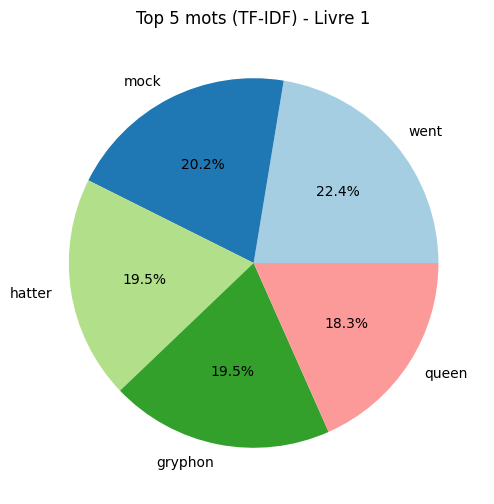

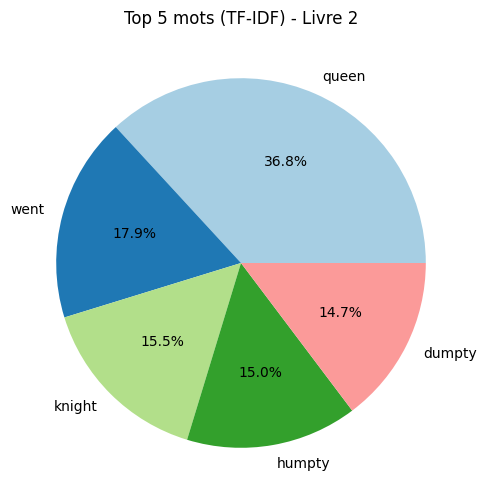

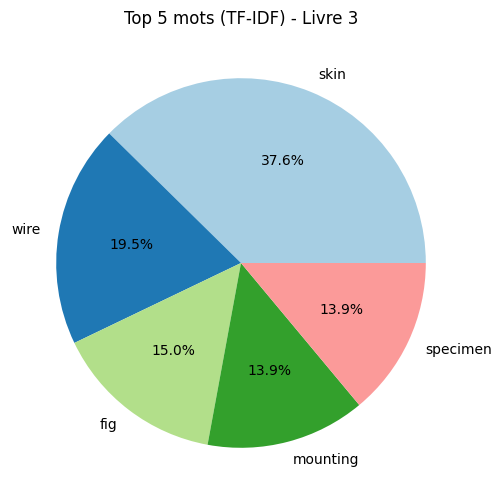

Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.


In [11]:
import numpy as np

# --- Visualisation TF-IDF (Étape Finale) ---
# Nous récupérons les 5 mots avec le score TF-IDF le plus élevé pour chaque livre

for i in range(len(corpus_joined)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    # On récupère les indices des 5 meilleurs scores
    top_tfidf_indices = tfidf_scores.argsort()[-5:][::-1]

    top_tfidf_words = [tfidf_features[idx] for idx in top_tfidf_indices]
    top_tfidf_values = [tfidf_scores[idx] for idx in top_tfidf_indices]

    # Création du graphique
    plt.figure(figsize=(6, 6))
    plt.pie(top_tfidf_values, labels=top_tfidf_words, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 mots (TF-IDF) - Livre {i+1}")
    plt.show()

print("Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.")

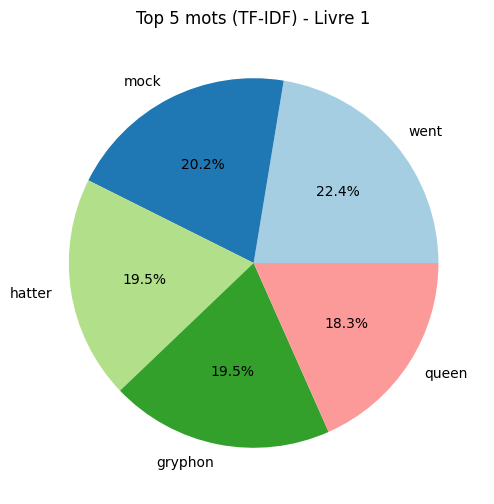

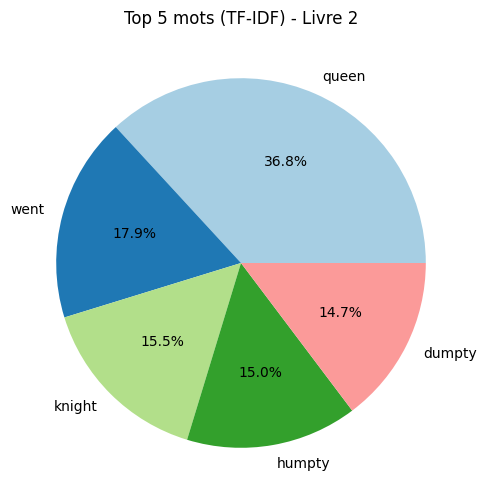

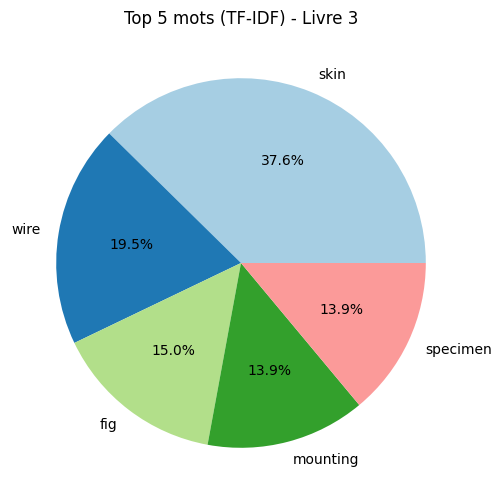

Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.


In [10]:
import numpy as np

# --- Visualisation TF-IDF (Étape Finale) ---
# Nous récupérons les 5 mots avec le score TF-IDF le plus élevé pour chaque livre

for i in range(len(corpus_joined)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    # On récupère les indices des 5 meilleurs scores
    top_tfidf_indices = tfidf_scores.argsort()[-5:][::-1]

    top_tfidf_words = [tfidf_features[idx] for idx in top_tfidf_indices]
    top_tfidf_values = [tfidf_scores[idx] for idx in top_tfidf_indices]

    # Création du graphique
    plt.figure(figsize=(6, 6))
    plt.pie(top_tfidf_values, labels=top_tfidf_words, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 mots (TF-IDF) - Livre {i+1}")
    plt.show()

print("Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.")